# Analysis

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

In [ ]:
def extract_mean(value):
    if isinstance(value, str):
        return float(value.split('$\\pm$')[0])
    else:
        return value

def jaccard_sim(data1, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)
    # data1 = (data1 - data1.min()) / (data1.max() - data1.min())
    # data2 = (data2 - data2.min()) / (data2.max() - data2.min())
    return jaccard_score([x>0.5 for x in data1], [x>0.5 for x in data2])

def jaccard_heatmap(data):
    data = data[~data.index.str.contains('NCN')]
    res = np.zeros((len(data), len(data)))
    for idx in range(len(data)):
        for idx2 in range(len(data)):
            if idx < idx2:
                res[idx][idx2] = jaccard_sim(data.iloc[idx], data.iloc[idx2])
    res += np.transpose(res) + np.identity(len(data))
    heatmap(pd.DataFrame(res, index=data.index, columns=data.index), 'Corelation Overlap', False)

def heatmap(data: pd.DataFrame, Title: str, normalized=True):
    data = data.copy()
    data = data.T
    if 'pretrain_time' in data.index:
        data = data.drop('pretrain_time')
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    if normalized:
        normalized_data = (data - data.min(axis=1).values[:, np.newaxis]) / (data.max(axis=1).values[:, np.newaxis] - data.min(axis=1).values[:, np.newaxis])
    else:
        normalized_data = data
    fig, ax = plt.subplots(figsize=(12, 12))
    im = ax.imshow(normalized_data)

    plt.xticks(rotation=90)

    ax.set_yticks(range(len(data.index)), labels=data.index,
                  rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(range(len(data.columns)), labels=data.columns)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            text_color = 'white' if normalized_data.iloc[i, j] < np.mean(normalized_data) else 'black'
            text = ax.text(j, i, f"{data.iloc[i, j]:.2f}",
                           ha="center", va="center", color=text_color)

    ax.set_title(Title)
    fig.tight_layout()
    plt.show()

Cora-FULL mlp
\begin{tabular}{llllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
baseline & 50.16$\pm$4.8 & 59.87$\pm$2.78 & 71.4$\pm$1.62 & 77.83$\pm$2.01 & 90.69$\pm$0.88 & 92.37$\pm$0.67 & nan$\pm$nan \\
grace_random & 48.9$\pm$4.88 & 60.19$\pm$2.76 & 73.33$\pm$1.73 & 80.69$\pm$1.6 & 91.45$\pm$0.81 & 92.96$\pm$0.6 & 19.04$\pm$0.13 \\
grace_deg & 29.73$\pm$6.42 & 46.25$\pm$6.56 & 67.6$\pm$2.94 & 80.91$\pm$1.33 & 91.95$\pm$0.58 & 92.17$\pm$0.69 & 19.19$\pm$0.08 \\
grace_pr & 31.23$\pm$7.11 & 45.55$\pm$7.04 & 67.26$\pm$5.77 & 80.98$\pm$3.51 & 92.13$\pm$1.14 & 92.33$\pm$1.19 & 19.15$\pm$0.02 \\
grace_evc & 33.4$\pm$5.46 & 47.57$\pm$6.06 & 68.09$\pm$3.75 & 79.82$\pm$3.37 & 91.92$\pm$0.68 & 92.32$\pm$0.81 & 19.15$\pm$0.04 \\
grace_scom & 48.88$\pm$6.25 & 61.23$\pm$4.28 & 74.83$\pm$1.53 & 81.59$\pm$1.4 & 91.79$\pm$0.71 & 93.3$\pm$0.44 & 20.27$\pm$0.09 \\
grace_sbm & 34.93$\pm$4.84 & 43.95$\pm$3.63 & 56.82$\pm$2.11 & 66.07$\pm$2.04 

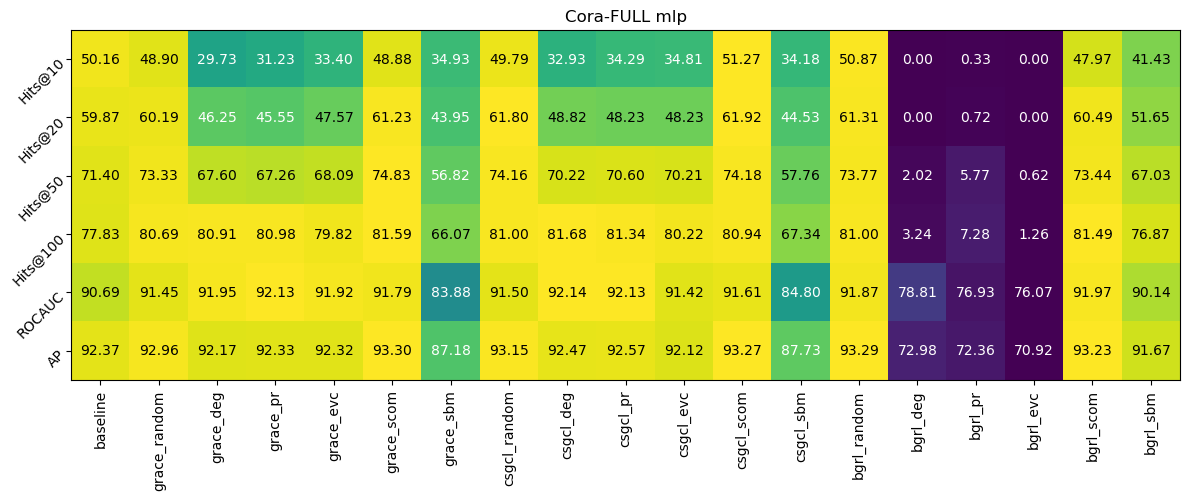

,baseline,grace_random,grace_deg,grace_pr,grace_evc,grace_scom,grace_sbm,csgcl_random,csgcl_deg,csgcl_pr,csgcl_evc,csgcl_scom,csgcl_sbm,bgrl_random,bgrl_deg,bgrl_pr,bgrl_evc,bgrl_scom,bgrl_sbm
metrics,,,,,,,,,,,,,,,,,,,
Hits@10,50.16$\pm$4.8,48.9$\pm$4.88,29.73$\pm$6.42,31.23$\pm$7.11,33.4$\pm$5.46,48.88$\pm$6.25,34.93$\pm$4.84,49.79$\pm$5.65,32.93$\pm$5.69,34.29$\pm$7.8,34.81$\pm$5.86,51.27$\pm$4.74,34.18$\pm$4.06,50.87$\pm$8.4,0.0$\pm$0.0,0.33$\pm$1.0,0.0$\pm$0.0,47.97$\pm$9.93,41.43$\pm$9.67
Hits@20,59.87$\pm$2.78,60.19$\pm$2.76,46.25$\pm$6.56,45.55$\pm$7.04,47.57$\pm$6.06,61.23$\pm$4.28,43.95$\pm$3.63,61.8$\pm$3.21,48.82$\pm$5.59,48.23$\pm$6.12,48.23$\pm$6.6,61.92$\pm$2.28,44.53$\pm$4.94,61.31$\pm$7.1,0.0$\pm$0.0,0.72$\pm$2.16,0.0$\pm$0.0,60.49$\pm$8.72,51.65$\pm$8.21
Hits@50,71.4$\pm$1.62,73.33$\pm$1.73,67.6$\pm$2.94,67.26$\pm$5.77,68.09$\pm$3.75,74.83$\pm$1.53,56.82$\pm$2.11,74.16$\pm$1.37,70.22$\pm$3.9,70.6$\pm$3.75,70.21$\pm$3.58,74.18$\pm$1.78,57.76$\pm$2.0,73.77$\pm$3.23,2.02$\pm$6.06,5.77$\pm$13.32,0.62$\pm$1.85,73.44$\pm$2.55,67.03$\pm$7.43
Hits@100,77.83$\pm$2.01,80.69$\pm$1.6,80.91$\pm$1.33,80.98$\pm$3.51,79.82$\pm$3.37,81.59$\pm$1.4,66.07$\pm$2.04,81.0$\pm$1.57,81.68$\pm$2.01,81.34$\pm$1.0,80.22$\pm$2.28,80.94$\pm$0.86,67.34$\pm$1.44,81.0$\pm$1.32,3.24$\pm$9.73,7.28$\pm$16.34,1.26$\pm$3.78,81.49$\pm$1.35,76.87$\pm$4.31
ROCAUC,90.69$\pm$0.88,91.45$\pm$0.81,91.95$\pm$0.58,92.13$\pm$1.14,91.92$\pm$0.68,91.79$\pm$0.71,83.88$\pm$1.02,91.5$\pm$1.04,92.14$\pm$0.79,92.13$\pm$0.55,91.42$\pm$0.97,91.61$\pm$0.55,84.8$\pm$1.02,91.87$\pm$0.71,78.81$\pm$4.54,76.93$\pm$7.69,76.07$\pm$8.37,91.97$\pm$1.01,90.14$\pm$1.26
AP,92.37$\pm$0.67,92.96$\pm$0.6,92.17$\pm$0.69,92.33$\pm$1.19,92.32$\pm$0.81,93.3$\pm$0.44,87.18$\pm$0.72,93.15$\pm$0.63,92.47$\pm$0.65,92.57$\pm$0.49,92.12$\pm$0.88,93.27$\pm$0.38,87.73$\pm$0.78,93.29$\pm$0.71,72.98$\pm$4.74,72.36$\pm$6.79,70.92$\pm$7.4,93.23$\pm$0.53,91.67$\pm$1.51
pretrain_time,nan$\pm$nan,19.04$\pm$0.13,19.19$\pm$0.08,19.15$\pm$0.02,19.15$\pm$0.04,20.27$\pm$0.09,866.8$\pm$23.27,20.67$\pm$0.09,20.74$\pm$0.13,20.7$\pm$0.09,20.67$\pm$0.04,22.3$\pm$0.17,895.48$\pm$32.54,19.01$\pm$0.1,19.45$\pm$0.09,18.95$\pm$0.52,18.1$\pm$0.11,19.36$\pm$0.06,846.79$\pm$30.39


In [4]:
data_sbm = pd.read_csv('./full_output_cora_res.csv', sep=';').T
data_sbm.columns = data_sbm.loc['metrics']
data_sbm.drop(index='metrics', inplace=True)

print('Cora-FULL mlp')
print(data_sbm.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm, 'Cora-FULL mlp')
display(data_sbm.T)

## SBM: Cora full vs CORA - test

SBM Cora-FULL mlp
\begin{tabular}{lllllllll}
\toprule
 & metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
\multirow[t]{4}{*}{full} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 27.68$\pm$0.0 & 42.18$\pm$0.0 & 58.2$\pm$0.0 & 65.88$\pm$0.0 & 83.88$\pm$0.0 & 86.77$\pm$0.0 & 135.02$\pm$0.0 \\
 & csgcl_sbm & 36.02$\pm$0.0 & 48.82$\pm$0.0 & 58.86$\pm$0.0 & 68.44$\pm$0.0 & 85.37$\pm$0.0 & 88.41$\pm$0.0 & 135.5$\pm$0.0 \\
 & bgrl_sbm & 29.29$\pm$0.0 & 39.05$\pm$0.0 & 51.56$\pm$0.0 & 65.97$\pm$0.0 & 89.29$\pm$0.0 & 89.24$\pm$0.0 & 135.32$\pm$0.0 \\
\cline{1-9}
\multirow[t]{4}{*}{-test} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 38.1$\pm$0.0 & 45.31$\pm$0.0 & 57.54$\pm$0.0 & 68.72$\pm$0.0 & 85.93$\pm$0.0 & 88.55$\pm$0.0 & 144.55$\pm$0.0 \\
 & csgcl_sbm & 33.18$\pm$0.0 

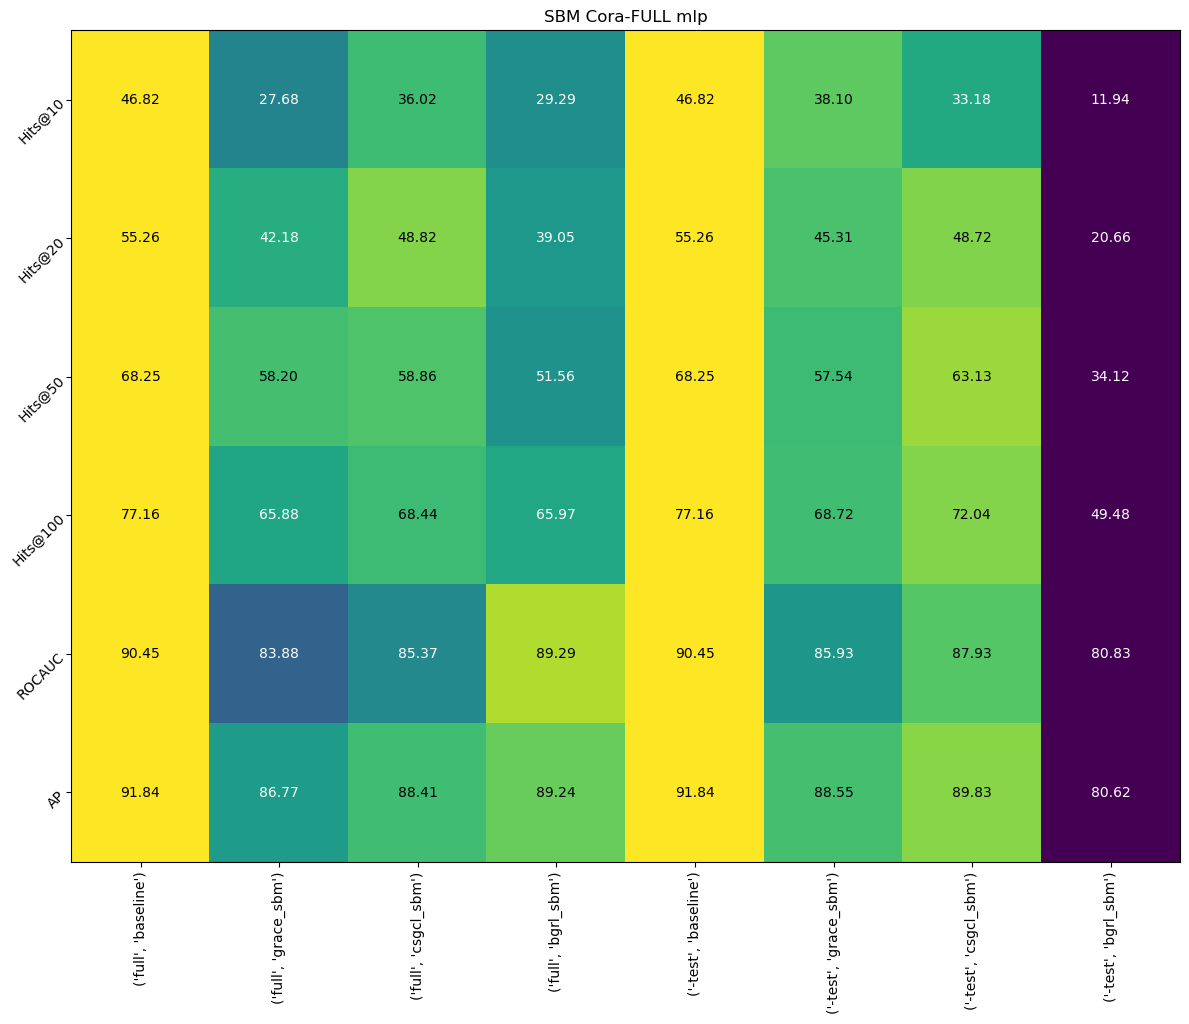

full                                                 \
                    baseline       grace_sbm      csgcl_sbm        bgrl_sbm   
metrics                                                                       
Hits@10        46.82$\pm$0.0   27.68$\pm$0.0  36.02$\pm$0.0   29.29$\pm$0.0   
Hits@20        55.26$\pm$0.0   42.18$\pm$0.0  48.82$\pm$0.0   39.05$\pm$0.0   
Hits@50        68.25$\pm$0.0    58.2$\pm$0.0  58.86$\pm$0.0   51.56$\pm$0.0   
Hits@100       77.16$\pm$0.0   65.88$\pm$0.0  68.44$\pm$0.0   65.97$\pm$0.0   
ROCAUC         90.45$\pm$0.0   83.88$\pm$0.0  85.37$\pm$0.0   89.29$\pm$0.0   
AP             91.84$\pm$0.0   86.77$\pm$0.0  88.41$\pm$0.0   89.24$\pm$0.0   
pretrain_time    nan$\pm$nan  135.02$\pm$0.0  135.5$\pm$0.0  135.32$\pm$0.0   

                       -test                                                  
                    baseline       grace_sbm       csgcl_sbm        bgrl_sbm  
metrics                                                                       
Hits@10        46.82$\pm$0.0    38.1$\pm$0.0   33.18$\pm$0.0   11.94$\pm$0.0  
Hits@20        55.26$\pm$0.0   45.31$\pm$0.0   48.72$\pm$0.0   20.66$\pm$0.0  
Hits@50        68.25$\pm$0.0   57.54$\pm$0.0   63.13$\pm$0.0   34.12$\pm$0.0  
Hits@100       77.16$\pm$0.0   68.72$\pm$0.0   72.04$\pm$0.0   49.48$\pm$0.0  
ROCAUC         90.45$\pm$0.0   85.93$\pm$0.0   87.93$\pm$0.0   80.83$\pm$0.0  
AP             91.84$\pm$0.0   88.55$\pm$0.0   89.83$\pm$0.0   80.62$\pm$0.0  
pretrain_time    nan$\pm$nan  144.55$\pm$0.0  144.32$\pm$0.0  144.34$\pm$0.0

In [9]:
data_sbm = pd.read_csv('./cora_sbm_full_res.csv', sep=';').T
data_sbm.columns = data_sbm.loc['metrics']
data_sbm.drop(index='metrics', inplace=True)

data_sbm2 = pd.read_csv('./cora-test_sbm_res.csv', sep=';').T
data_sbm2.columns = data_sbm2.loc['metrics']
data_sbm2.drop(index='metrics', inplace=True)

data_sbm = pd.concat([data_sbm, data_sbm2], keys=['full', '-test'])

print('SBM Cora-FULL mlp')
print(data_sbm.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm, 'SBM Cora-FULL mlp')
display(data_sbm.T)